In [1]:
import pandas as pd

file_path = 'df_prop.csv'
df = pd.read_csv(file_path)

df.head()

,ID_FAM_ANON,VL_RENDA_MEDIA_FAM,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,IN_FORMULARIO_SUP2_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,...,PCT_CRIANCAS_7A11,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,classe_renda
0,4923789,798.0,2.0,33,4557,0,3.0,1.0,1.0,1.0,...,0.000000,0.000000,0.333333,0.333333,0.333333,0.0,0.0,0,0,2
1,9217971,217.0,2.0,52,21858,0,4.0,1.0,1.0,1.0,...,0.000000,0.750000,0.000000,0.250000,0.000000,0.0,0.0,0,0,0
2,5227921,32.0,2.0,33,3500,0,1.0,1.0,2.0,1.0,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0,0,0
3,676981,486.0,2.0,15,5536,0,6.0,1.0,1.0,1.0,...,0.166667,0.333333,0.000000,0.333333,0.000000,0.0,0.0,0,0,1
4,2478731,1661.0,2.0,26,11101,0,3.0,1.0,1.0,1.0,...,0.000000,0.333333,0.333333,0.333333,0.000000,0.0,0.0,0,0,2


In [2]:
df = df.drop(columns=['VL_RENDA_MEDIA_FAM', 'PBF', 'DIAS_ATUALIZACAO'])

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 47 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  float64
 2   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 4   IN_FORMULARIO_SUP2_FAM        1000000 non-null  int64  
 5   QT_PESSOAS_DOMIC_FAM          1000000 non-null  float64
 6   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  float64
 7   CO_ESPECIE_DOMIC_FAM          1000000 non-null  float64
 8   CO_LOCAL_DOMIC_FAM            1000000 non-null  float64
 9   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 10  QT_COMODOS_DORMITORIO_FAM     1000000 non-null  float64
 11  CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 12  CO_MATERIAL_PISO_FAM         

In [4]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
)

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression


In [5]:
df['classe_renda'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 1000000 entries, 0 to 999999
Series name: classe_renda
Non-Null Count    Dtype
--------------    -----
1000000 non-null  int64
dtypes: int64(1)
memory usage: 7.6 MB


In [6]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'IN_FORMULARIO_SUP2_FAM', 'QT_PESSOAS_DOMIC_FAM',
       'QT_FAMILIAS_DOMIC_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
       'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
       'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
       'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
       'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
       'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'DIAS_CADASTRO',
       'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA', 'IDADE_REFERENCIA',
       'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
       'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
       'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
       'CO_TRABALHO_12_ME

## Análise de correlação das variáveis

In [7]:
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency

# ---- 1) Listas das categorias ----

cat_num_cols = [
    'IN_TRABALHO_INFANTIL_FAM', 'IN_FORMULARIO_SUP2_FAM',
    'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
    'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM',
    'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM',
    'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
    'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_INDIGENA_FAM',
    'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
    'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA',
    'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
    'CO_SABE_LER_ESCREVER_MEMB', 'IN_FREQUENTA_ESCOLA_MEMB',
    'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
    'CO_TRABALHOU_SEMANA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
    'CO_AGRICULTURA_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB',
    'CO_TRABALHO_12_MESES_MEMB',
]

bool_cols = [
    'TEM_CRIANCA_SEM_ESCOLA',
    'TEM_ADOLESCENTE_SEM_ESCOLA',
    ]

pct_cols = [
    'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
    'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
    'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
    'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA',
]


quant_cols = [
    'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
    'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
    'DIAS_CADASTRO', 'IDADE_REFERENCIA',
]

# Conjuntos auxiliares para testar tipo rapidamente
cat_all = cat_num_cols + bool_cols    # tratadas como categóricas
num_all = quant_cols + pct_cols                    # tratadas como numéricas

set_cat = set(cat_all)
set_num = set(num_all)

# Todas as variáveis consideradas
all_vars = cat_all + num_all

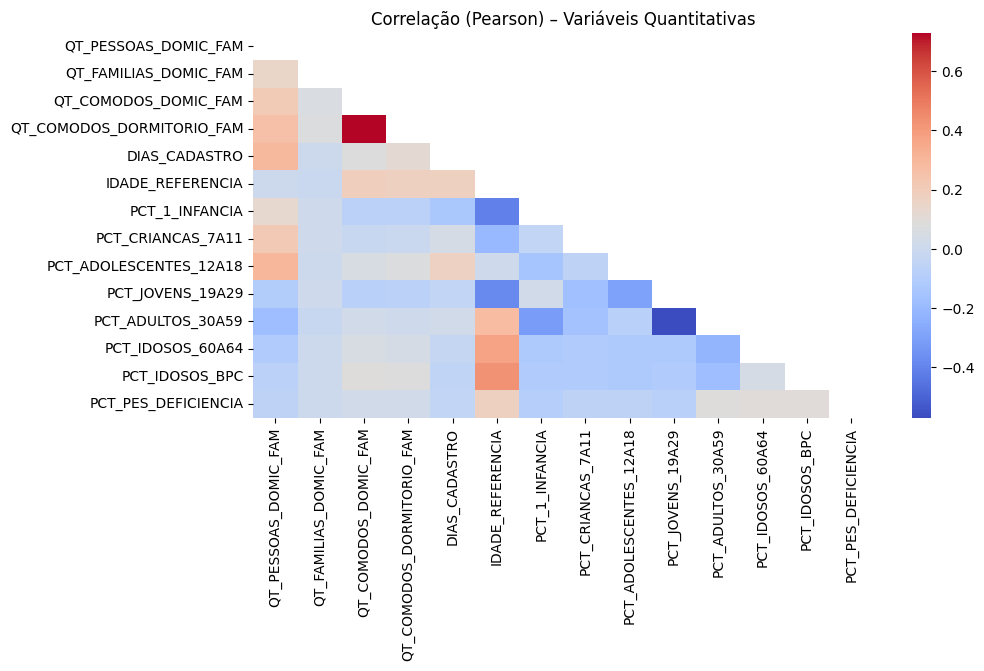

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Selecionar apenas quantitativas
df_quant = df[quant_cols + pct_cols]

# Matriz de correlação Pearson
corr_quant = df_quant.corr(method='pearson')

# Máscara acima da diagonal
mask = np.triu(np.ones_like(corr_quant, dtype=bool))

plt.figure(figsize=(10, 5))
sns.heatmap(
    corr_quant.round(2),
    annot=False,
    cmap='coolwarm',
    mask=mask
)
plt.title("Correlação (Pearson) – Variáveis Quantitativas")
plt.show()


In [9]:
# Converter matriz para formato longo (var1, var2, corr)
corr_pairs = (
    corr_quant
        .where(np.triu(np.ones(corr_quant.shape), k=1).astype(bool))  # apenas acima da diagonal
        .stack()
        .reset_index()
)
corr_pairs.columns = ['var1', 'var2', 'corr']

# Ordenar pelas correlações mais fortes (em valor absoluto)
corr_pairs_sorted = corr_pairs.reindex(corr_pairs['corr'].abs().sort_values(ascending=False).index)

# Mostrar top 20
corr_pairs_sorted.head(20)


,var1,var2,corr
25,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,0.732411
81,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,-0.569183
61,IDADE_REFERENCIA,PCT_IDOSOS_BPC,0.429200
55,IDADE_REFERENCIA,PCT_1_INFANCIA,-0.405760
58,IDADE_REFERENCIA,PCT_JOVENS_19A29,-0.384637
60,IDADE_REFERENCIA,PCT_IDOSOS_60A64,0.373138
66,PCT_1_INFANCIA,PCT_ADULTOS_30A59,-0.315740
7,QT_PESSOAS_DOMIC_FAM,PCT_ADOLESCENTES_12A18,0.302078
76,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,-0.301845
3,QT_PESSOAS_DOMIC_FAM,DIAS_CADASTRO,0.288733


In [10]:
from scipy.stats import chi2_contingency

def cramers_v(x, y):
    t = pd.crosstab(x, y)
    if t.shape[0] <= 1 or t.shape[1] <= 1:
        return np.nan
    chi2, p, dof, expected = chi2_contingency(t)
    n = t.to_numpy().sum()
    r, k = t.shape
    return np.sqrt(chi2 / (n*(min(r,k)-1)))


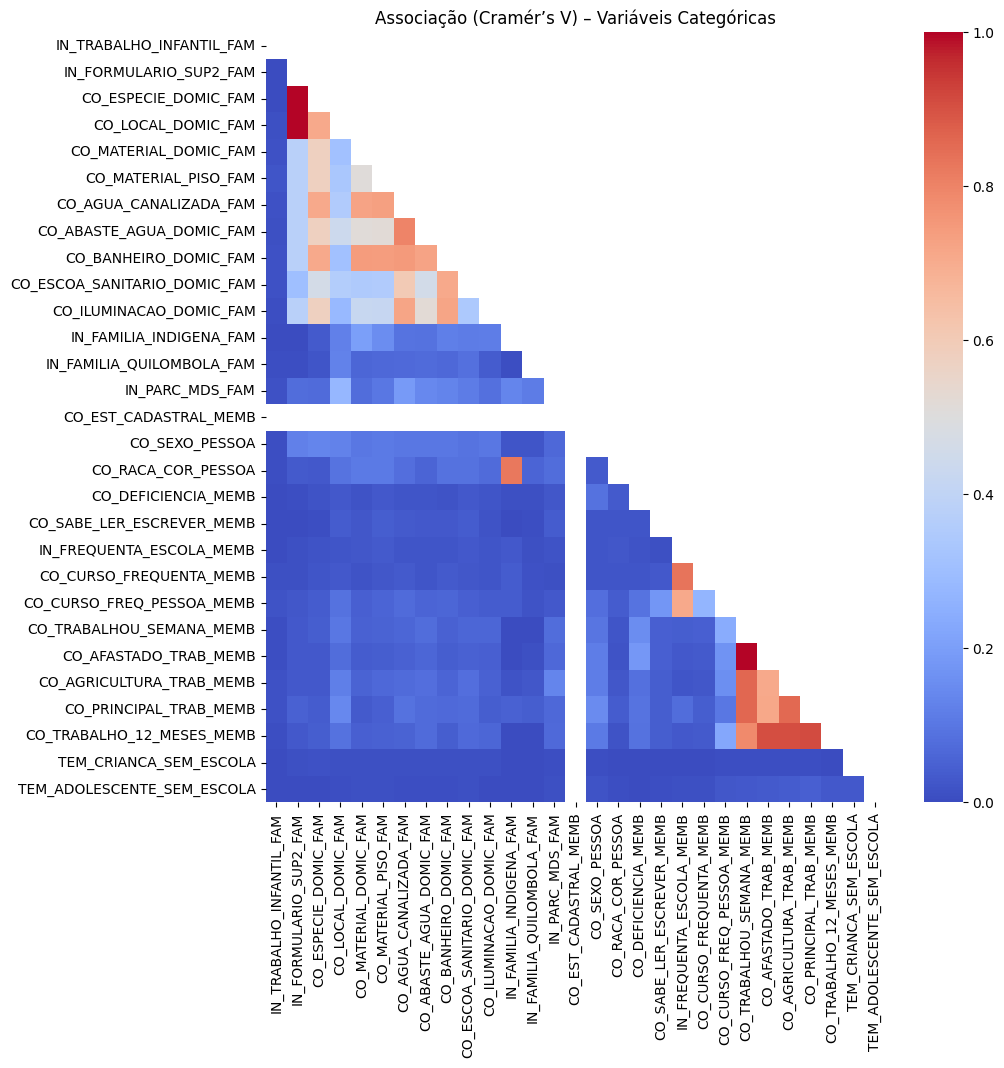

In [11]:
# Selecionar todas as categóricas
df_cat = df[cat_num_cols + bool_cols]

# Matriz vazia
cramers_mat = pd.DataFrame(index=df_cat.columns, columns=df_cat.columns)

# Preencher matriz
for c1 in df_cat.columns:
    for c2 in df_cat.columns:
        if c1 == c2:
            cramers_mat.loc[c1, c2] = 1
        else:
            cramers_mat.loc[c1, c2] = cramers_v(df_cat[c1], df_cat[c2])

# Converter para float
cramers_mat = cramers_mat.astype(float)

# Máscara
mask = np.triu(np.ones_like(cramers_mat, dtype=bool))

plt.figure(figsize=(10, 10))
sns.heatmap(
    cramers_mat,
    annot=False,
    cmap='coolwarm',
    mask=mask,
    vmax=1,
    vmin=0
)
plt.title("Associação (Cramér’s V) – Variáveis Categóricas")
plt.show()


In [12]:
import numpy as np
import pandas as pd

# partindo de cramers_mat já calculada

# 1) Pegar só a parte acima da diagonal para evitar duplicação
cramers_pairs = (
    cramers_mat
        .where(np.triu(np.ones(cramers_mat.shape), k=1).astype(bool))  # mantém só acima da diagonal
        .stack()                                                       # transforma em série longa
        .reset_index()
)

cramers_pairs.columns = ['var1', 'var2', 'cramers_v']

# 2) Ordenar pelas maiores associações
cramers_pairs_sorted = cramers_pairs.sort_values('cramers_v', ascending=False)

# 3) Ver as 30 maiores associações
print("Top 30 pares com maior Cramér's V:")
print(cramers_pairs_sorted.head(10))


Top 30 pares com maior Cramér's V:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999740
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999688
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.913718
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.908484
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.907089
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.862738
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.859960
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.856020
333  IN_FREQUENTA_ESCOLA_MEMB    CO_CURSO_FREQUENTA_MEMB   0.834171


In [13]:
# Definir um limiar para "associação muito alta"
threshold = 0.80

cramers_high = cramers_pairs_sorted[cramers_pairs_sorted['cramers_v'] >= threshold]

print(f"\nPares com Cramér's V >= {threshold}:")
print(cramers_high)



Pares com Cramér's V >= 0.8:
                         var1                       var2  cramers_v
357  CO_TRABALHOU_SEMANA_MEMB      CO_AFASTADO_TRAB_MEMB   1.000000
27     IN_FORMULARIO_SUP2_FAM       CO_ESPECIE_DOMIC_FAM   0.999740
28     IN_FORMULARIO_SUP2_FAM         CO_LOCAL_DOMIC_FAM   0.999688
372    CO_PRINCIPAL_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.913718
369  CO_AGRICULTURA_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.908484
365     CO_AFASTADO_TRAB_MEMB  CO_TRABALHO_12_MESES_MEMB   0.907089
359  CO_TRABALHOU_SEMANA_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.862738
358  CO_TRABALHOU_SEMANA_MEMB   CO_AGRICULTURA_TRAB_MEMB   0.859960
368  CO_AGRICULTURA_TRAB_MEMB     CO_PRINCIPAL_TRAB_MEMB   0.856020
333  IN_FREQUENTA_ESCOLA_MEMB    CO_CURSO_FREQUENTA_MEMB   0.834171
245   IN_FAMILIA_INDIGENA_FAM         CO_RACA_COR_PESSOA   0.824619


In [14]:
df = df.drop(columns=['IN_FORMULARIO_SUP2_FAM', 'CO_TRABALHOU_SEMANA_MEMB', 'CO_AGRICULTURA_TRAB_MEMB', 'IN_FAMILIA_INDIGENA_FAM', 'IN_FREQUENTA_ESCOLA_MEMB', 'CO_TRABALHO_12_MESES_MEMB'])

In [15]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'DIAS_CADASTRO',
       'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA', 'IDADE_REFERENCIA',
       'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
       'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59',
       'PCT_IDOSOS_60A64', 'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENC

In [16]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_CRIANCAS_7A11,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,classe_renda
0,4923789,2.0,33,4557,3.0,1.0,1.0,1.0,4,1.0,...,0.000000,0.000000,0.333333,0.333333,0.333333,0.0,0.0,0,0,2
1,9217971,2.0,52,21858,4.0,1.0,1.0,1.0,4,1.0,...,0.000000,0.750000,0.000000,0.250000,0.000000,0.0,0.0,0,0,0
2,5227921,2.0,33,3500,1.0,1.0,2.0,1.0,-1,-1.0,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0,0,0
3,676981,2.0,15,5536,6.0,1.0,1.0,1.0,2,1.0,...,0.166667,0.333333,0.000000,0.333333,0.000000,0.0,0.0,0,0,1
4,2478731,2.0,26,11101,3.0,1.0,1.0,1.0,6,3.0,...,0.000000,0.333333,0.333333,0.333333,0.000000,0.0,0.0,0,0,2


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 41 columns):
 #   Column                        Non-Null Count    Dtype  
---  ------                        --------------    -----  
 0   ID_FAM_ANON                   1000000 non-null  int64  
 1   IN_TRABALHO_INFANTIL_FAM      1000000 non-null  float64
 2   CO_MUNIC_IBGE_2_FAM           1000000 non-null  int64  
 3   CO_MUNIC_IBGE_5_FAM           1000000 non-null  int64  
 4   QT_PESSOAS_DOMIC_FAM          1000000 non-null  float64
 5   QT_FAMILIAS_DOMIC_FAM         1000000 non-null  float64
 6   CO_ESPECIE_DOMIC_FAM          1000000 non-null  float64
 7   CO_LOCAL_DOMIC_FAM            1000000 non-null  float64
 8   QT_COMODOS_DOMIC_FAM          1000000 non-null  int64  
 9   QT_COMODOS_DORMITORIO_FAM     1000000 non-null  float64
 10  CO_MATERIAL_DOMIC_FAM         1000000 non-null  int64  
 11  CO_MATERIAL_PISO_FAM          1000000 non-null  int64  
 12  CO_AGUA_CANALIZADA_FAM       

In [18]:
df.head()

,ID_FAM_ANON,IN_TRABALHO_INFANTIL_FAM,CO_MUNIC_IBGE_2_FAM,CO_MUNIC_IBGE_5_FAM,QT_PESSOAS_DOMIC_FAM,QT_FAMILIAS_DOMIC_FAM,CO_ESPECIE_DOMIC_FAM,CO_LOCAL_DOMIC_FAM,QT_COMODOS_DOMIC_FAM,QT_COMODOS_DORMITORIO_FAM,...,PCT_CRIANCAS_7A11,PCT_ADOLESCENTES_12A18,PCT_JOVENS_19A29,PCT_ADULTOS_30A59,PCT_IDOSOS_60A64,PCT_IDOSOS_BPC,PCT_PES_DEFICIENCIA,TEM_CRIANCA_SEM_ESCOLA,TEM_ADOLESCENTE_SEM_ESCOLA,classe_renda
0,4923789,2.0,33,4557,3.0,1.0,1.0,1.0,4,1.0,...,0.000000,0.000000,0.333333,0.333333,0.333333,0.0,0.0,0,0,2
1,9217971,2.0,52,21858,4.0,1.0,1.0,1.0,4,1.0,...,0.000000,0.750000,0.000000,0.250000,0.000000,0.0,0.0,0,0,0
2,5227921,2.0,33,3500,1.0,1.0,2.0,1.0,-1,-1.0,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.0,0.0,0,0,0
3,676981,2.0,15,5536,6.0,1.0,1.0,1.0,2,1.0,...,0.166667,0.333333,0.000000,0.333333,0.000000,0.0,0.0,0,0,1
4,2478731,2.0,26,11101,3.0,1.0,1.0,1.0,6,3.0,...,0.000000,0.333333,0.333333,0.333333,0.000000,0.0,0.0,0,0,2


## Pre-processamento
### Detectando as colunas categóricas binárias e multicategóricas

In [19]:
df.columns

Index(['ID_FAM_ANON', 'IN_TRABALHO_INFANTIL_FAM', 'CO_MUNIC_IBGE_2_FAM',
       'CO_MUNIC_IBGE_5_FAM', 'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
       'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'QT_COMODOS_DOMIC_FAM',
       'QT_COMODOS_DORMITORIO_FAM', 'CO_MATERIAL_DOMIC_FAM',
       'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM',
       'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM',
       'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM',
       'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM', 'DIAS_CADASTRO',
       'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA', 'IDADE_REFERENCIA',
       'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
       'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB',
       'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB',
       'CO_PRINCIPAL_TRAB_MEMB', 'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
       'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29', 'PCT_ADULTOS_30A59',
       'PCT_IDOSOS_60A64', 'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENC

In [20]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import numpy as np

# Listas de cada categoria
cat_num_cols = [
        'IN_TRABALHO_INFANTIL_FAM', 'CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM',
        'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM','CO_AGUA_CANALIZADA_FAM',
        'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM',
        'CO_ILUMINACAO_DOMIC_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'IN_PARC_MDS_FAM',
        'CO_EST_CADASTRAL_MEMB', 'CO_SEXO_PESSOA', 'CO_RACA_COR_PESSOA', 'CO_DEFICIENCIA_MEMB',
        'CO_SABE_LER_ESCREVER_MEMB', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB',
        'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB'
    ]

bool_cols = [
        'TEM_CRIANCA_SEM_ESCOLA',
        'TEM_ADOLESCENTE_SEM_ESCOLA',
        ]

pct_cols = [
        'PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
        'PCT_ADOLESCENTES_12A18', 'PCT_JOVENS_19A29',
        'PCT_ADULTOS_30A59', 'PCT_IDOSOS_60A64',
        'PCT_IDOSOS_BPC', 'PCT_PES_DEFICIENCIA',
    ]

quant_cols = [
        'QT_PESSOAS_DOMIC_FAM', 'QT_FAMILIAS_DOMIC_FAM',
        'QT_COMODOS_DOMIC_FAM', 'QT_COMODOS_DORMITORIO_FAM',
        'DIAS_CADASTRO', 'IDADE_REFERENCIA',
    ]

geo_cols = ['CO_MUNIC_IBGE_2_FAM', 'CO_MUNIC_IBGE_5_FAM']

target_col = "classe_renda"
id_col = "ID_FAM_ANON"


In [21]:
# X e y brutos
X = df.drop(columns=[target_col, id_col])
y = df[target_col]

# Garante que as listas só pegam colunas que realmente existem
cat_num_cols_eff = [c for c in cat_num_cols if c in X.columns]
bool_cols_eff    = [c for c in bool_cols    if c in X.columns]
pct_cols_eff     = [c for c in pct_cols     if c in X.columns]
quant_cols_eff   = [c for c in quant_cols   if c in X.columns]
geo_cols_eff     = [c for c in geo_cols     if c in X.columns]

# Detectar binárias e multicategóricas dentro de cat_num_cols
binary_cols = []
multicat_cols = []

for col in cat_num_cols_eff:
    n_unique = X[col].nunique()
    if n_unique == 2:
        binary_cols.append(col)
    elif n_unique > 2:
        multicat_cols.append(col)

print("Binárias:", binary_cols)
print("Multicategóricas:", multicat_cols)

Binárias: ['IN_TRABALHO_INFANTIL_FAM', 'IN_FAMILIA_QUILOMBOLA_FAM', 'CO_SEXO_PESSOA', 'CO_DEFICIENCIA_MEMB', 'CO_SABE_LER_ESCREVER_MEMB']
Multicategóricas: ['CO_ESPECIE_DOMIC_FAM', 'CO_LOCAL_DOMIC_FAM', 'CO_MATERIAL_DOMIC_FAM', 'CO_MATERIAL_PISO_FAM', 'CO_AGUA_CANALIZADA_FAM', 'CO_ABASTE_AGUA_DOMIC_FAM', 'CO_BANHEIRO_DOMIC_FAM', 'CO_ESCOA_SANITARIO_DOMIC_FAM', 'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM', 'CO_RACA_COR_PESSOA', 'CO_CURSO_FREQUENTA_MEMB', 'CO_CURSO_FREQ_PESSOA_MEMB', 'CO_AFASTADO_TRAB_MEMB', 'CO_PRINCIPAL_TRAB_MEMB']


In [22]:
# Pipeline quantitativas contínuas
pipeline_quant = Pipeline([
    ("impute", SimpleImputer(strategy="median")),
    ("scale", MinMaxScaler()),
])

In [23]:
#Pipeline categorias multiclasses (One-hot)
pipeline_multicat = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

In [24]:
# Pipeline para binárias
pipeline_binary = Pipeline([
    ("impute", SimpleImputer(strategy="most_frequent")),
    ])


In [25]:
# Pipeline percentuais (já estão entre 0 e 1)
pipeline_pct = "passthrough"

In [26]:
# Pipeline booleanas
pipeline_bool = "passthrough"

In [27]:
#Pipeline geográficas (não usar one-hot pois vai criar muitas colunas)
pipeline_geo = "passthrough"

In [28]:
#Construindo ColumnsTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ("quant", pipeline_quant, quant_cols),
        ("pct", pipeline_pct, pct_cols),
        ("bool", pipeline_bool, bool_cols),
        ("binary", pipeline_binary, binary_cols),
        ("multicat", pipeline_multicat, multicat_cols),
        ("geo", pipeline_geo, geo_cols),
    ],
    remainder="drop"  # remove colunas que não foram especificadas
)

## Separando em treino e teste

In [29]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

### Visualizando a transformação

In [30]:
preprocessor.fit(X_train)

ColumnTransformer(transformers=[('quant',
                                 Pipeline(steps=[('impute',
                                                  SimpleImputer(strategy='median')),
                                                 ('scale', MinMaxScaler())]),
                                 ['QT_PESSOAS_DOMIC_FAM',
                                  'QT_FAMILIAS_DOMIC_FAM',
                                  'QT_COMODOS_DOMIC_FAM',
                                  'QT_COMODOS_DORMITORIO_FAM', 'DIAS_CADASTRO',
                                  'IDADE_REFERENCIA']),
                                ('pct', 'passthrough',
                                 ['PCT_1_INFANCIA', 'PCT_CRIANCAS_7A11',
                                  'PCT_ADOLESCENTES_12A18', 'P...
                                  'CO_MATERIAL_PISO_FAM',
                                  'CO_AGUA_CANALIZADA_FAM',
                                  'CO_ABASTE_AGUA_DOMIC_FAM',
                                  'CO_BANHEIRO_DOMIC_FAM',
                                  'CO_ESCOA_SANITARIO_DOMIC_FAM',
                                  'CO_ILUMINACAO_DOMIC_FAM', 'IN_PARC_MDS_FAM',
                                  'CO_RACA_COR_PESSOA',
                                  'CO_CURSO_FREQUENTA_MEMB',
                                  'CO_CURSO_FREQ_PESSOA_MEMB',
                                  'CO_AFASTADO_TRAB_MEMB',
                                  'CO_PRINCIPAL_TRAB_MEMB']),
                                ('geo', 'passthrough',
                                 ['CO_MUNIC_IBGE_2_FAM',
                                  'CO_MUNIC_IBGE_5_FAM'])])

In [31]:
X_train_trans = preprocessor.transform(X_train)

feature_names = preprocessor.get_feature_names_out()

import pandas as pd
df_train_trans = pd.DataFrame(X_train_trans, columns=feature_names)

df_train_trans.head()

,quant__QT_PESSOAS_DOMIC_FAM,quant__QT_FAMILIAS_DOMIC_FAM,quant__QT_COMODOS_DOMIC_FAM,quant__QT_COMODOS_DORMITORIO_FAM,quant__DIAS_CADASTRO,quant__IDADE_REFERENCIA,pct__PCT_1_INFANCIA,pct__PCT_CRIANCAS_7A11,pct__PCT_ADOLESCENTES_12A18,pct__PCT_JOVENS_19A29,...,multicat__CO_PRINCIPAL_TRAB_MEMB_4.0,multicat__CO_PRINCIPAL_TRAB_MEMB_5.0,multicat__CO_PRINCIPAL_TRAB_MEMB_6.0,multicat__CO_PRINCIPAL_TRAB_MEMB_7.0,multicat__CO_PRINCIPAL_TRAB_MEMB_8.0,multicat__CO_PRINCIPAL_TRAB_MEMB_9.0,multicat__CO_PRINCIPAL_TRAB_MEMB_10.0,multicat__CO_PRINCIPAL_TRAB_MEMB_11.0,geo__CO_MUNIC_IBGE_2_FAM,geo__CO_MUNIC_IBGE_5_FAM
0,0.043956,0.023256,0.072917,0.053333,0.107510,0.425287,0.000000,0.0,0.0,0.666667,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,26.0,6002.0
1,0.065934,0.023256,0.062500,0.040000,0.287046,0.287356,0.400000,0.2,0.2,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,31.0,17603.0
2,0.043956,0.023256,0.072917,0.040000,0.056138,0.160920,0.333333,0.0,0.0,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,53.0,108.0
3,0.043956,0.023256,0.062500,0.040000,0.400487,0.367816,0.000000,0.0,0.0,0.666667,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,41.0,19509.0
4,0.065934,0.023256,0.052083,0.026667,0.169791,0.206897,0.600000,0.2,0.0,0.000000,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,35.0,47809.0


### Comparando diversos modelos

In [32]:
!pip install xgboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
!pip install catboost --quiet


[notice] A new release of pip is available: 25.1.1 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [34]:
# ============================================================
# TREINO + AVALIAÇÃO (accuracy, f1, AUC, precision, recall)
# e SALVAMENTO dos modelos (pipelines) já treinados
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score
)

from xgboost import XGBClassifier
from catboost import CatBoostClassifier

# ------------------------------------------------------------
# 0) CONFIG: pasta onde os modelos serão salvos
# ------------------------------------------------------------
SAVE_DIR = "modelos_treinados"
os.makedirs(SAVE_DIR, exist_ok=True)

# ------------------------------------------------------------
# 1) MODELOS
# (assume que você já importou RandomForestClassifier, LogisticRegression,
#  GradientBoostingClassifier, HistGradientBoostingClassifier, etc.)
# ------------------------------------------------------------
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=300, random_state=42, n_jobs=-1
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000, multi_class="auto", n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingClassifier(random_state=42),
    "HistGradientBoosting": HistGradientBoostingClassifier(random_state=42),

    "XGBoost": XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ),

    "CatBoost": CatBoostClassifier(
        iterations=300,
        learning_rate=0.1,
        depth=6,
        loss_function="MultiClass",
        eval_metric="MultiClass",
        random_seed=42,
        verbose=False
        # thread_count=-1  # opcional
    ),
}

# ------------------------------------------------------------
# 2) TREINO + AVALIAÇÃO + SALVAR
# ------------------------------------------------------------
pipes = {}      # guarda em memória
results = []    # guarda métricas em tabela

for name, clf in models.items():
    print(f"\nTreinando modelo: {name}")

    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])

    pipe.fit(X_train, y_train)

    # guarda pipeline treinado em memória
    pipes[name] = pipe

    # salva pipeline treinado em disco
    model_path = os.path.join(SAVE_DIR, f"{name}.joblib")
    joblib.dump(pipe, model_path)

    # predições
    y_pred = pipe.predict(X_test)

    # métricas principais
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")

    # precisão e revocação (macro e weighted)
    prec_m = precision_score(y_test, y_pred, average="macro", zero_division=0)
    rec_m  = recall_score(y_test, y_pred, average="macro", zero_division=0)

    prec_w = precision_score(y_test, y_pred, average="weighted", zero_division=0)
    rec_w  = recall_score(y_test, y_pred, average="weighted", zero_division=0)

    # AUC (se existir predict_proba)
    try:
        y_proba = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        auc = np.nan

    results.append({
        "modelo": name,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "precision_macro": prec_m,
        "recall_macro": rec_m,
        "precision_weighted": prec_w,
        "recall_weighted": rec_w,
        "auc_weighted_ovr": auc,
        "arquivo_modelo": model_path
    })

# ------------------------------------------------------------
# 3) RESULTADOS (tabela final)
# ------------------------------------------------------------
df_results = pd.DataFrame(results).sort_values("accuracy", ascending=False)
df_results





Treinando modelo: RandomForest

Treinando modelo: LogisticRegression


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



Treinando modelo: GradientBoosting

Treinando modelo: HistGradientBoosting

Treinando modelo: XGBoost

Treinando modelo: CatBoost


,modelo,accuracy,f1_weighted,f1_macro,precision_macro,recall_macro,precision_weighted,recall_weighted,auc_weighted_ovr,arquivo_modelo
4,XGBoost,0.684825,0.662119,0.566864,0.634010,0.544964,0.666222,0.684825,0.807051,modelos_treinados\XGBoost.joblib
3,HistGradientBoosting,0.683590,0.661037,0.565345,0.630167,0.543955,0.664383,0.683590,0.805617,modelos_treinados\HistGradientBoosting.joblib
5,CatBoost,0.681795,0.657480,0.559135,0.631553,0.537665,0.662875,0.681795,0.803628,modelos_treinados\CatBoost.joblib
2,GradientBoosting,0.673430,0.641327,0.529513,0.629762,0.511594,0.654758,0.673430,0.793084,modelos_treinados\GradientBoosting.joblib
0,RandomForest,0.671475,0.647508,0.547250,0.609488,0.528166,0.649484,0.671475,0.787844,modelos_treinados\RandomForest.joblib
1,LogisticRegression,0.631925,0.583211,0.446156,0.537474,0.445294,0.590096,0.631925,0.739710,modelos_treinados\LogisticRegression.joblib


In [35]:
# ============================================================
# COMPARAÇÃO + TUNING focado na Classe 2 (reduzir FN sem inflar FP)
# Modelos: HistGradientBoosting, XGBoost, CatBoost
# ============================================================

import os
import numpy as np
import pandas as pd
import joblib

from sklearn.metrics import (
    classification_report, confusion_matrix,
    make_scorer
)
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV

# -----------------------------
# 1) CONFIG
# -----------------------------
SAVE_DIR = "modelos_treinados"
MODEL_NAMES = ["HistGradientBoosting", "XGBoost", "CatBoost"]
CLASS_FOCUS = 2

PRECISAO_MIN_CL2 = 0.60
W_RECALL = 2.0
W_FP = 1.0
EPS = 1e-12

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# -----------------------------
# 2) FUNÇÕES AUXILIARES
# -----------------------------
def metricas_classe_foco(y_true, y_pred, classe=2):
    # y_true é Series 1D (pelo seu pipeline). Aqui só garantimos y_pred 1D.
    y_pred = np.asarray(y_pred).ravel()

    labels = np.unique(np.concatenate([np.array(y_true), y_pred]))
    cm = confusion_matrix(y_true, y_pred, labels=labels)

    idx = {lab: i for i, lab in enumerate(labels)}
    i = idx[classe]

    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - (TP + FN + FP)

    prec = TP / (TP + FP + EPS)
    rec  = TP / (TP + FN + EPS)
    f1   = 2 * prec * rec / (prec + rec + EPS)

    return {
        "TP_cl2": int(TP), "FN_cl2": int(FN), "FP_cl2": int(FP), "TN_cl2": int(TN),
        "precision_cl2": float(prec), "recall_cl2": float(rec), "f1_cl2": float(f1)
    }

def score_classe2_sem_inflar_fp(estimator, X, y):
    y_pred = estimator.predict(X).ravel()  # <<< FIX
    m = metricas_classe_foco(y, y_pred, classe=CLASS_FOCUS)

    if m["precision_cl2"] < PRECISAO_MIN_CL2:
        return -1e6

    n_not2 = np.sum(np.array(y) != CLASS_FOCUS)
    fp_rate = m["FP_cl2"] / (n_not2 + EPS)

    return (W_RECALL * m["recall_cl2"]) - (W_FP * fp_rate)

custom_scorer = make_scorer(score_classe2_sem_inflar_fp, greater_is_better=True, needs_proba=False)

# -----------------------------
# 3) CARREGAR MODELOS SALVOS E COMPARAR (baseline)
# -----------------------------
pipes = {}
for name in MODEL_NAMES:
    path = os.path.join(SAVE_DIR, f"{name}.joblib")
    pipes[name] = joblib.load(path)

baseline_rows = []
for name, pipe in pipes.items():
    y_pred = pipe.predict(X_test).ravel()  # <<< FIX
    m2 = metricas_classe_foco(y_test, y_pred, classe=CLASS_FOCUS)

    baseline_rows.append({
        "modelo": name,
        **m2
    })

df_baseline = pd.DataFrame(baseline_rows).sort_values(["recall_cl2","precision_cl2"], ascending=False)
print("\n=== BASELINE (teste) focado na Classe 2 ===")
display(df_baseline)

for name, pipe in pipes.items():
    print(f"\n--- Relatório de classificação (TESTE) | {name} ---")
    print(classification_report(y_test, pipe.predict(X_test).ravel(), digits=4))  # <<< FIX

# -----------------------------
# 4) ESPAÇOS DE HIPERPARÂMETROS
# -----------------------------
param_distributions = {
    "HistGradientBoosting": {
        "model__learning_rate": np.linspace(0.03, 0.15, 8),
        "model__max_depth": [3, 4, 5, 6, None],
        "model__max_leaf_nodes": [15, 31, 63, 127],
        "model__min_samples_leaf": [10, 20, 40, 80],
        "model__l2_regularization": np.logspace(-4, 1, 10),
        "model__max_bins": [128, 255]
    },

    "XGBoost": {
        "model__n_estimators": [300, 500, 800],
        "model__learning_rate": np.linspace(0.03, 0.15, 8),
        "model__max_depth": [3, 4, 5, 6, 8],
        "model__min_child_weight": [1, 3, 5, 8, 12],
        "model__subsample": np.linspace(0.6, 1.0, 5),
        "model__colsample_bytree": np.linspace(0.6, 1.0, 5),
        "model__reg_lambda": np.logspace(-2, 2, 10),
        "model__reg_alpha": np.logspace(-3, 1, 10),
        "model__gamma": [0, 0.5, 1, 2, 5],
    },

    "CatBoost": {
        "model__iterations": [300, 500, 800],
        "model__learning_rate": np.linspace(0.03, 0.15, 8),
        "model__depth": [4, 5, 6, 7, 8],
        "model__l2_leaf_reg": np.logspace(-2, 2, 10),
        "model__random_strength": [0.5, 1, 2, 5, 10],
        "model__bagging_temperature": [0, 0.5, 1, 2, 5]
    }
}

# -----------------------------
# 5) RODAR RANDOM SEARCH
# -----------------------------
best_models = {}
tuning_summary = []

for name in MODEL_NAMES:
    pipe = pipes[name]

    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions[name],
        n_iter=30,
        scoring=custom_scorer,
        cv=cv,
        random_state=42,
        n_jobs=-1,
        verbose=1
    )

    print(f"\n=== TUNING: {name} (foco na classe 2) ===")
    search.fit(X_train, y_train)

    best_pipe = search.best_estimator_
    best_models[name] = best_pipe

    y_pred_best = best_pipe.predict(X_test).ravel()  # <<< FIX
    m2_best = metricas_classe_foco(y_test, y_pred_best, classe=CLASS_FOCUS)

    tuning_summary.append({
        "modelo": name,
        "best_cv_score_custom": float(search.best_score_),
        **m2_best,
        "best_params": search.best_params_
    })

df_tuning = pd.DataFrame(tuning_summary).sort_values(["recall_cl2", "precision_cl2"], ascending=False)
print("\n=== RESULTADO DO TUNING (teste) focado na Classe 2 ===")
display(df_tuning)

# -----------------------------
# 6) SALVAR OS MODELOS TUNADOS
# -----------------------------
SAVE_DIR_TUNED = "modelos_treinados_tunados"
os.makedirs(SAVE_DIR_TUNED, exist_ok=True)

for name, pipe in best_models.items():
    path = os.path.join(SAVE_DIR_TUNED, f"{name}_TUNADO.joblib")
    joblib.dump(pipe, path)
    print(f"Salvo: {path}")

# -----------------------------
# 7) RELATÓRIO FINAL
# -----------------------------
for name, pipe in best_models.items():
    print(f"\n--- Relatório (TESTE) | {name} TUNADO ---")
    print(classification_report(y_test, pipe.predict(X_test).ravel(), digits=4))  # <<< FIX




=== BASELINE (teste) focado na Classe 2 ===


,modelo,TP_cl2,FN_cl2,FP_cl2,TN_cl2,precision_cl2,recall_cl2,f1_cl2
2,CatBoost,104760,11948,37547,45745,0.736155,0.897625,0.808911
1,XGBoost,104564,12144,36730,46562,0.740046,0.895945,0.810567
0,HistGradientBoosting,104385,12323,36650,46642,0.740135,0.894412,0.809993



--- Relatório de classificação (TESTE) | HistGradientBoosting ---
              precision    recall  f1-score   support

           0     0.6254    0.3110    0.4155     27594
           1     0.5250    0.4264    0.4706     55698
           2     0.7401    0.8944    0.8100    116708

    accuracy                         0.6836    200000
   macro avg     0.6302    0.5440    0.5653    200000
weighted avg     0.6644    0.6836    0.6610    200000


--- Relatório de classificação (TESTE) | XGBoost ---
              precision    recall  f1-score   support

           0     0.6350    0.3116    0.4180     27594
           1     0.5270    0.4274    0.4720     55698
           2     0.7400    0.8959    0.8106    116708

    accuracy                         0.6848    200000
   macro avg     0.6340    0.5450    0.5669    200000
weighted avg     0.6662    0.6848    0.6621    200000


--- Relatório de classificação (TESTE) | CatBoost ---
              precision    recall  f1-score   support

       

C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1107: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



=== TUNING: XGBoost (foco na classe 2) ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits


...


=== TUNING: CatBoost (foco na classe 2) ===
Fitting 5 folds for each of 30 candidates, totalling 150 fits


C:\Users\Admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\model_selection\_search.py:1107: UserWarning: One or more of the test scores are non-finite: [nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan nan
 nan nan nan nan nan nan nan nan nan nan nan nan]
  warnings.warn(



=== RESULTADO DO TUNING (teste) focado na Classe 2 ===


,modelo,best_cv_score_custom,TP_cl2,FN_cl2,FP_cl2,TN_cl2,precision_cl2,recall_cl2,f1_cl2,best_params
1,XGBoost,NaN,105193,11515,38471,44821,0.732215,0.901335,0.808021,"{'model__subsample': 1.0, 'model__reg_lambda':..."
2,CatBoost,NaN,104803,11905,37172,46120,0.738179,0.897993,0.810281,"{'model__random_strength': 10, 'model__learnin..."
0,HistGradientBoosting,NaN,104215,12493,36464,46828,0.740800,0.892955,0.809792,"{'model__min_samples_leaf': 40, 'model__max_le..."


Salvo: modelos_treinados_tunados\HistGradientBoosting_TUNADO.joblib
Salvo: modelos_treinados_tunados\XGBoost_TUNADO.joblib
Salvo: modelos_treinados_tunados\CatBoost_TUNADO.joblib

--- Relatório (TESTE) | HistGradientBoosting TUNADO ---
              precision    recall  f1-score   support

           0     0.6247    0.3138    0.4178     27594
           1     0.5240    0.4277    0.4710     55698
           2     0.7408    0.8930    0.8098    116708

    accuracy                         0.6835    200000
   macro avg     0.6298    0.5448    0.5662    200000
weighted avg     0.6644    0.6835    0.6613    200000


--- Relatório (TESTE) | XGBoost TUNADO ---
              precision    recall  f1-score   support

           0     0.6330    0.2734    0.3819     27594
           1     0.5222    0.4165    0.4634     55698
           2     0.7322    0.9013    0.8080    116708

    accuracy                         0.6797    200000
   macro avg     0.6291    0.5304    0.5511    200000
weighted avg 

# Pipeline processamento + Modelo (XGBoost)

In [ ]:
pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", XGBClassifier(
        n_estimators=300,
        learning_rate=0.1,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="multi:softprob",
        eval_metric="mlogloss",
        tree_method="hist",
        random_state=42,
        n_jobs=-1
    ))
])

pipeline_xgb.fit(X_train, y_train)

## Avaliação completa do Modelo

### Predições do teste

In [ ]:
y_pred = pipeline_xgb.predict(X_test)
y_proba = pipeline_xgb.predict_proba(X_test)  # para AUC

### Acurácia e F1

In [ ]:
acc = accuracy_score(y_test, y_pred)
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_weighted = f1_score(y_test, y_pred, average="weighted")

print(f"Acurácia: {acc:.3f}")
print(f"F1 macro: {f1_macro:.3f}")
print(f"F1 weighted: {f1_weighted:.3f}")

### Classification report

In [ ]:
print("Classification report:")
print(classification_report(y_test, y_pred))

### Matriz de confusão

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Matriz de Confusão – XGBoost")
plt.show()

## Ajustando os parâmetros

### Criando uma amostra estratificada para testar outros parâmetros

In [ ]:
from sklearn.model_selection import train_test_split

# usa 30% do X_train só para o tuning 
X_tune, _, y_tune, _ = train_test_split(
    X_train,
    y_train,
    train_size=0.3,
    stratify=y_train,
    random_state=42
)

print(X_tune.shape, y_tune.shape)


### Modelo base

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb_base = XGBClassifier(
    objective="multi:softprob",
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42,
    n_jobs=-1   # paralelismo fica aqui, dentro do modelo
)

pipeline_xgb = Pipeline([
    ("preprocess", preprocessor),
    ("model", xgb_base)
])


### Busca de hiperparâmetros - Usando CV

In [ ]:
param_dist = {
    "model__n_estimators": randint(200, 600),
    "model__learning_rate": uniform(0.02, 0.10),   # ~ 0.02 a 0.12
    "model__max_depth": randint(3, 8),
    "model__subsample": uniform(0.6, 0.3),         # ~ 0.6 a 0.9
    "model__colsample_bytree": uniform(0.6, 0.3),  # ~ 0.6 a 0.9
    "model__min_child_weight": randint(1, 6),
    "model__gamma": uniform(0.0, 0.3),
    "model__reg_lambda": uniform(1.0, 8.0),
    "model__reg_alpha": uniform(0.0, 1.5),
}


In [ ]:
search = RandomizedSearchCV(
    estimator=pipeline_xgb,
    param_distributions=param_dist,
    n_iter=15,              # mais leve que 30
    cv=3,                   # se ainda der memória, pode baixar para 2
    scoring="f1_weighted",  # ou "accuracy"
    verbose=2,
    n_jobs=1,               # ***ponto chave pra evitar estouro de RAM***
    random_state=42
)

search.fit(X_tune, y_tune)

print("Melhor score (CV):", search.best_score_)
print("Melhores parâmetros:")
for k, v in search.best_params_.items():
    print(f"  {k}: {v}")


In [ ]:
best_model = search.best_estimator_

# agora treina com 100% do X_train
best_model.fit(X_train, y_train)

y_pred = best_model.predict(X_test)

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np

acc = accuracy_score(y_test, y_pred)
f1_w = f1_score(y_test, y_pred, average="weighted")
f1_m = f1_score(y_test, y_pred, average="macro")

try:
    y_proba = best_model.predict_proba(X_test)
    auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
except Exception:
    auc = np.nan

print("Resultados no teste:")
print("  accuracy:", acc)
print("  f1_weighted:", f1_w)
print("  f1_macro:", f1_m)
print("  auc_weighted_ovr:", auc)

### Busca de hiperparâmetros - usando 4 configurações manuais diferentes

In [ ]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score
import numpy as np
import pandas as pd

# 1) Dicionário com 4 configurações de XGBoost
xgb_configs = {
    # Config 1 – baseline (parecida com a que já funcionou bem)
    "XGB_baseline": {
        "n_estimators": 300,
        "learning_rate": 0.1,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 1,
        "gamma": 0.0,
        "reg_lambda": 1.0,
        "reg_alpha": 0.0,
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    },

    # Config 2 – mais suave: mais árvores, learning_rate menor
    "XGB_suave": {
        "n_estimators": 600,
        "learning_rate": 0.05,
        "max_depth": 6,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 3,
        "gamma": 0.1,
        "reg_lambda": 5.0,
        "reg_alpha": 0.0,
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    },

    # Config 3 – árvores mais rasas, foco em generalização
    "XGB_raso_regularizado": {
        "n_estimators": 700,
        "learning_rate": 0.04,
        "max_depth": 4,
        "subsample": 0.8,
        "colsample_bytree": 0.8,
        "min_child_weight": 5,
        "gamma": 0.2,
        "reg_lambda": 8.0,
        "reg_alpha": 0.5,
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    },

    # Config 4 – árvores mais profundas, mais capacidade (aceitando mais risco de overfitting)
    "XGB_profundo": {
        "n_estimators": 400,
        "learning_rate": 0.07,
        "max_depth": 8,
        "subsample": 0.7,
        "colsample_bytree": 0.7,
        "min_child_weight": 1,
        "gamma": 0.0,
        "reg_lambda": 2.0,
        "reg_alpha": 0.0,
        "objective": "multi:softprob",
        "eval_metric": "mlogloss",
        "tree_method": "hist",
        "random_state": 42,
        "n_jobs": -1
    }
}

results_xgb = []
best_pipelines = {}  # para guardar os pipelines treinados

for name, params in xgb_configs.items():
    print(f"\nTreinando configuração: {name}")
    
    clf = XGBClassifier(**params)
    
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", clf)
    ])
    
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    # métricas
    acc = accuracy_score(y_test, y_pred)
    f1_w = f1_score(y_test, y_pred, average="weighted")
    f1_m = f1_score(y_test, y_pred, average="macro")

    # AUC (se conseguir proba)
    try:
        y_proba = pipe.predict_proba(X_test)
        auc = roc_auc_score(y_test, y_proba, multi_class="ovr", average="weighted")
    except Exception:
        auc = np.nan

    results_xgb.append({
        "config": name,
        "accuracy": acc,
        "f1_weighted": f1_w,
        "f1_macro": f1_m,
        "auc_weighted_ovr": auc
    })

    best_pipelines[name] = pipe  # guarda o pipeline treinado

df_results_xgb = pd.DataFrame(results_xgb).sort_values("accuracy", ascending=False)
df_results_xgb


In [ ]:
melhor_pipe = best_pipelines["XGB_profundo"]

In [ ]:
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score,
    classification_report, confusion_matrix
)
import numpy as np
import pandas as pd

# ============================================================
# PREVISÕES DO MODELO
# ============================================================
y_pred = melhor_pipe.predict(X_test)

try:
    y_proba = melhor_pipe.predict_proba(X_test)
except Exception:
    y_proba = None

# ============================================================
# MÉTRICAS GERAIS DO MODELO
# ============================================================
acuracia = accuracy_score(y_test, y_pred)

precisao_ponderada = precision_score(
    y_test, y_pred, average="weighted", zero_division=0
)
precisao_macro = precision_score(
    y_test, y_pred, average="macro", zero_division=0
)

revocacao_ponderada = recall_score(
    y_test, y_pred, average="weighted", zero_division=0
)
revocacao_macro = recall_score(
    y_test, y_pred, average="macro", zero_division=0
)

f1_ponderado = f1_score(
    y_test, y_pred, average="weighted", zero_division=0
)
f1_macro = f1_score(
    y_test, y_pred, average="macro", zero_division=0
)

if y_proba is not None:
    auc_ponderado_ovr = roc_auc_score(
        y_test, y_proba, multi_class="ovr", average="weighted"
    )
else:
    auc_ponderado_ovr = np.nan

print("Resultados no conjunto de teste (XGB profundo):")
print("  Acurácia:", acuracia)
print("  Precisão (ponderada):", precisao_ponderada)
print("  Precisão (macro):", precisao_macro)
print("  Revocação (ponderada):", revocacao_ponderada)
print("  Revocação (macro):", revocacao_macro)
print("  F1-score (ponderado):", f1_ponderado)
print("  F1-score (macro):", f1_macro)
print("  AUC ponderado (One-vs-Rest):", auc_ponderado_ovr)

# ============================================================
# 1) RELATÓRIO DE CLASSIFICAÇÃO POR CLASSE DE RENDA
# ============================================================


nomes_classes = None 

print("\n--- Relatório de classificação por classe de renda ---")
print(
    classification_report(
        y_test,
        y_pred,
        target_names=nomes_classes,
        zero_division=0
    )
)

# Versão em DataFrame (útil para tabelas e gráficos)
relatorio_dict = classification_report(
    y_test,
    y_pred,
    target_names=nomes_classes,
    output_dict=True,
    zero_division=0
)

df_relatorio = pd.DataFrame(relatorio_dict).T

# Manter apenas as classes (remover médias e acurácia)
df_classes = df_relatorio.loc[
    [idx for idx in df_relatorio.index
     if idx not in ["accuracy", "macro avg", "weighted avg"]]
].copy()

# Ordenar da pior para a melhor classe (F1-score)
df_classes = df_classes.sort_values("f1-score")

print("\n--- Desempenho por classe de renda (ordenado por F1-score) ---")
display(df_classes)

# ============================================================
# 2) MATRIZ DE CONFUSÃO
# ============================================================

rotulos = np.unique(np.concatenate([np.array(y_test), np.array(y_pred)]))

matriz_confusao = confusion_matrix(
    y_test, y_pred, labels=rotulos
)

df_matriz_confusao = pd.DataFrame(
    matriz_confusao,
    index=rotulos,
    columns=rotulos
)

print("\n--- Matriz de confusão (linhas = classe real | colunas = classe prevista) ---")
display(df_matriz_confusao)

# Matriz normalizada por linha (percentual dentro da classe real)
matriz_confusao_norm = (
    matriz_confusao / matriz_confusao.sum(axis=1, keepdims=True)
)

df_matriz_confusao_norm = pd.DataFrame(
    matriz_confusao_norm,
    index=rotulos,
    columns=rotulos
)

print("\n--- Matriz de confusão normalizada (% dentro de cada classe real) ---")
display(df_matriz_confusao_norm)

# ============================================================
# 3) PRINCIPAIS CONFUSÕES ENTRE CLASSES
# ============================================================

lista_erros = []

for i, classe_real in enumerate(rotulos):
    for j, classe_prevista in enumerate(rotulos):
        if classe_real != classe_prevista and matriz_confusao[i, j] > 0:
            lista_erros.append(
                (
                    classe_real,
                    classe_prevista,
                    matriz_confusao[i, j],
                    matriz_confusao_norm[i, j]
                )
            )

df_erros = pd.DataFrame(
    lista_erros,
    columns=[
        "Classe real",
        "Classe prevista",
        "Quantidade de casos",
        "Percentual dentro da classe real"
    ]
)

df_erros = df_erros.sort_values(
    ["Percentual dentro da classe real", "Quantidade de casos"],
    ascending=False
)

print("\n--- Principais confusões entre classes de renda ---")
display(df_erros.head(15))




In [ ]:
# Classes de renda (ordem lógica)
rotulos_classes = [0, 1, 2]

nomes_classes = [
    "Pobreza",  # classe 0
    "Baixa renda",          # classe 1
    "Acime de 1/2"       # classe 2
]


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_metricas_por_classe(
    df_classes,
    y_test,
    y_pred,
    nomes_classes,
    titulo="Desempenho por classe"
):
    """
    Plota Precisão, Revocação e F1-score por classe (barras agrupadas)
    """

    # Garante a ordem correta das classes: 0, 1, 2
    classes = [0, 1, 2]
    nomes = nomes_classes

    # df_classes normalmente vem com índice string ("0","1","2")
    df_plot = df_classes.loc[[str(c) for c in classes], ["precision", "recall", "f1-score"]].copy()
    df_plot.index = nomes

    x = np.arange(len(df_plot))
    largura = 0.25

    plt.figure(figsize=(10, 4))

    plt.bar(x - largura, df_plot["precision"], width=largura, label="Precisão")
    plt.bar(x,           df_plot["recall"],    width=largura, label="Revocação")
    plt.bar(x + largura, df_plot["f1-score"],  width=largura, label="F1-score")

    plt.ylim(0, 1)
    plt.xticks(x, df_plot.index, rotation=20)
    plt.ylabel("Valor (0 a 1)")
    plt.title(titulo)
    plt.legend()

    # rótulos numéricos
    for i in range(len(df_plot)):
        plt.text(x[i] - largura, df_plot.iloc[i]["precision"] + 0.02,
                 f"{df_plot.iloc[i]['precision']:.2f}", ha="center")
        plt.text(x[i], df_plot.iloc[i]["recall"] + 0.02,
                 f"{df_plot.iloc[i]['recall']:.2f}", ha="center")
        plt.text(x[i] + largura, df_plot.iloc[i]["f1-score"] + 0.02,
                 f"{df_plot.iloc[i]['f1-score']:.2f}", ha="center")

    plt.tight_layout()
    plt.show()



In [ ]:
plot_metricas_por_classe(
    df_classes=df_classes,
    y_test=y_test,
    y_pred=y_pred,
    nomes_classes=nomes_classes,
    titulo="Desempenho do modelo por classe de renda"
)


### Análise da importância das variáveis

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# calcula a importância por permutação no conjunto de teste
result = permutation_importance(
    melhor_pipe,
    X_test,
    y_test,
    n_repeats=5,           
    scoring="f1_weighted", 
    n_jobs=1,
    random_state=42
)

# importância média por feature
importances_mean = result.importances_mean
importances_std = result.importances_std

# monta um DataFrame com as importâncias
df_importances = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": importances_mean,
    "importance_std": importances_std
}).sort_values("importance_mean", ascending=False)

df_importances.head(20)


In [ ]:
top_n = 20
top_features = df_importances.head(top_n)

plt.figure(figsize=(10, 8))
plt.barh(top_features["feature"], top_features["importance_mean"])
plt.gca().invert_yaxis()
plt.xlabel("Permutation importance (média da queda no score)")
plt.title("Top variáveis mais importantes – XGB_profundo")
plt.grid(axis="x")
plt.show()